変形開始
ノード数 = 100, 初期確率 p = 0.04, 段階数 = 20
rewires_per_step = 1000, beta = 1.8
[途中経過] 段階 1/20 : alpha = 0.05
[途中経過] 段階 2/20 : alpha = 0.10
[途中経過] 段階 3/20 : alpha = 0.15
[途中経過] 段階 4/20 : alpha = 0.20
[途中経過] 段階 5/20 : alpha = 0.25
[途中経過] 段階 6/20 : alpha = 0.30
[途中経過] 段階 7/20 : alpha = 0.35
[途中経過] 段階 8/20 : alpha = 0.40
[途中経過] 段階 9/20 : alpha = 0.45
[途中経過] 段階 10/20 : alpha = 0.50
[途中経過] 段階 11/20 : alpha = 0.55
[途中経過] 段階 12/20 : alpha = 0.60
[途中経過] 段階 13/20 : alpha = 0.65
[途中経過] 段階 14/20 : alpha = 0.70
[途中経過] 段階 15/20 : alpha = 0.75
[途中経過] 段階 16/20 : alpha = 0.80
[途中経過] 段階 17/20 : alpha = 0.85
[途中経過] 段階 18/20 : alpha = 0.90
[途中経過] 段階 19/20 : alpha = 0.95
[途中経過] 段階 20/20 : alpha = 1.00

ラプラシアン固有値を計算中
[固有値計算] 段階  0 | λ2=-0.0000, λmax=10.8522, 0固有値個数=4
[固有値計算] 段階  1 | λ2=0.0000, λmax=10.2399, 0固有値個数=5
[固有値計算] 段階  2 | λ2=-0.0000, λmax=11.9981, 0固有値個数=5
[固有値計算] 段階  3 | λ2=0.0000, λmax=10.9008, 0固有値個数=3
[固有値計算] 段階  4 | λ2=-0.0000, λmax=11.6462, 0固有値個数=6
[固有値計算] 段階  5 | λ2=-0.0000, λmax=13.7741, 0固

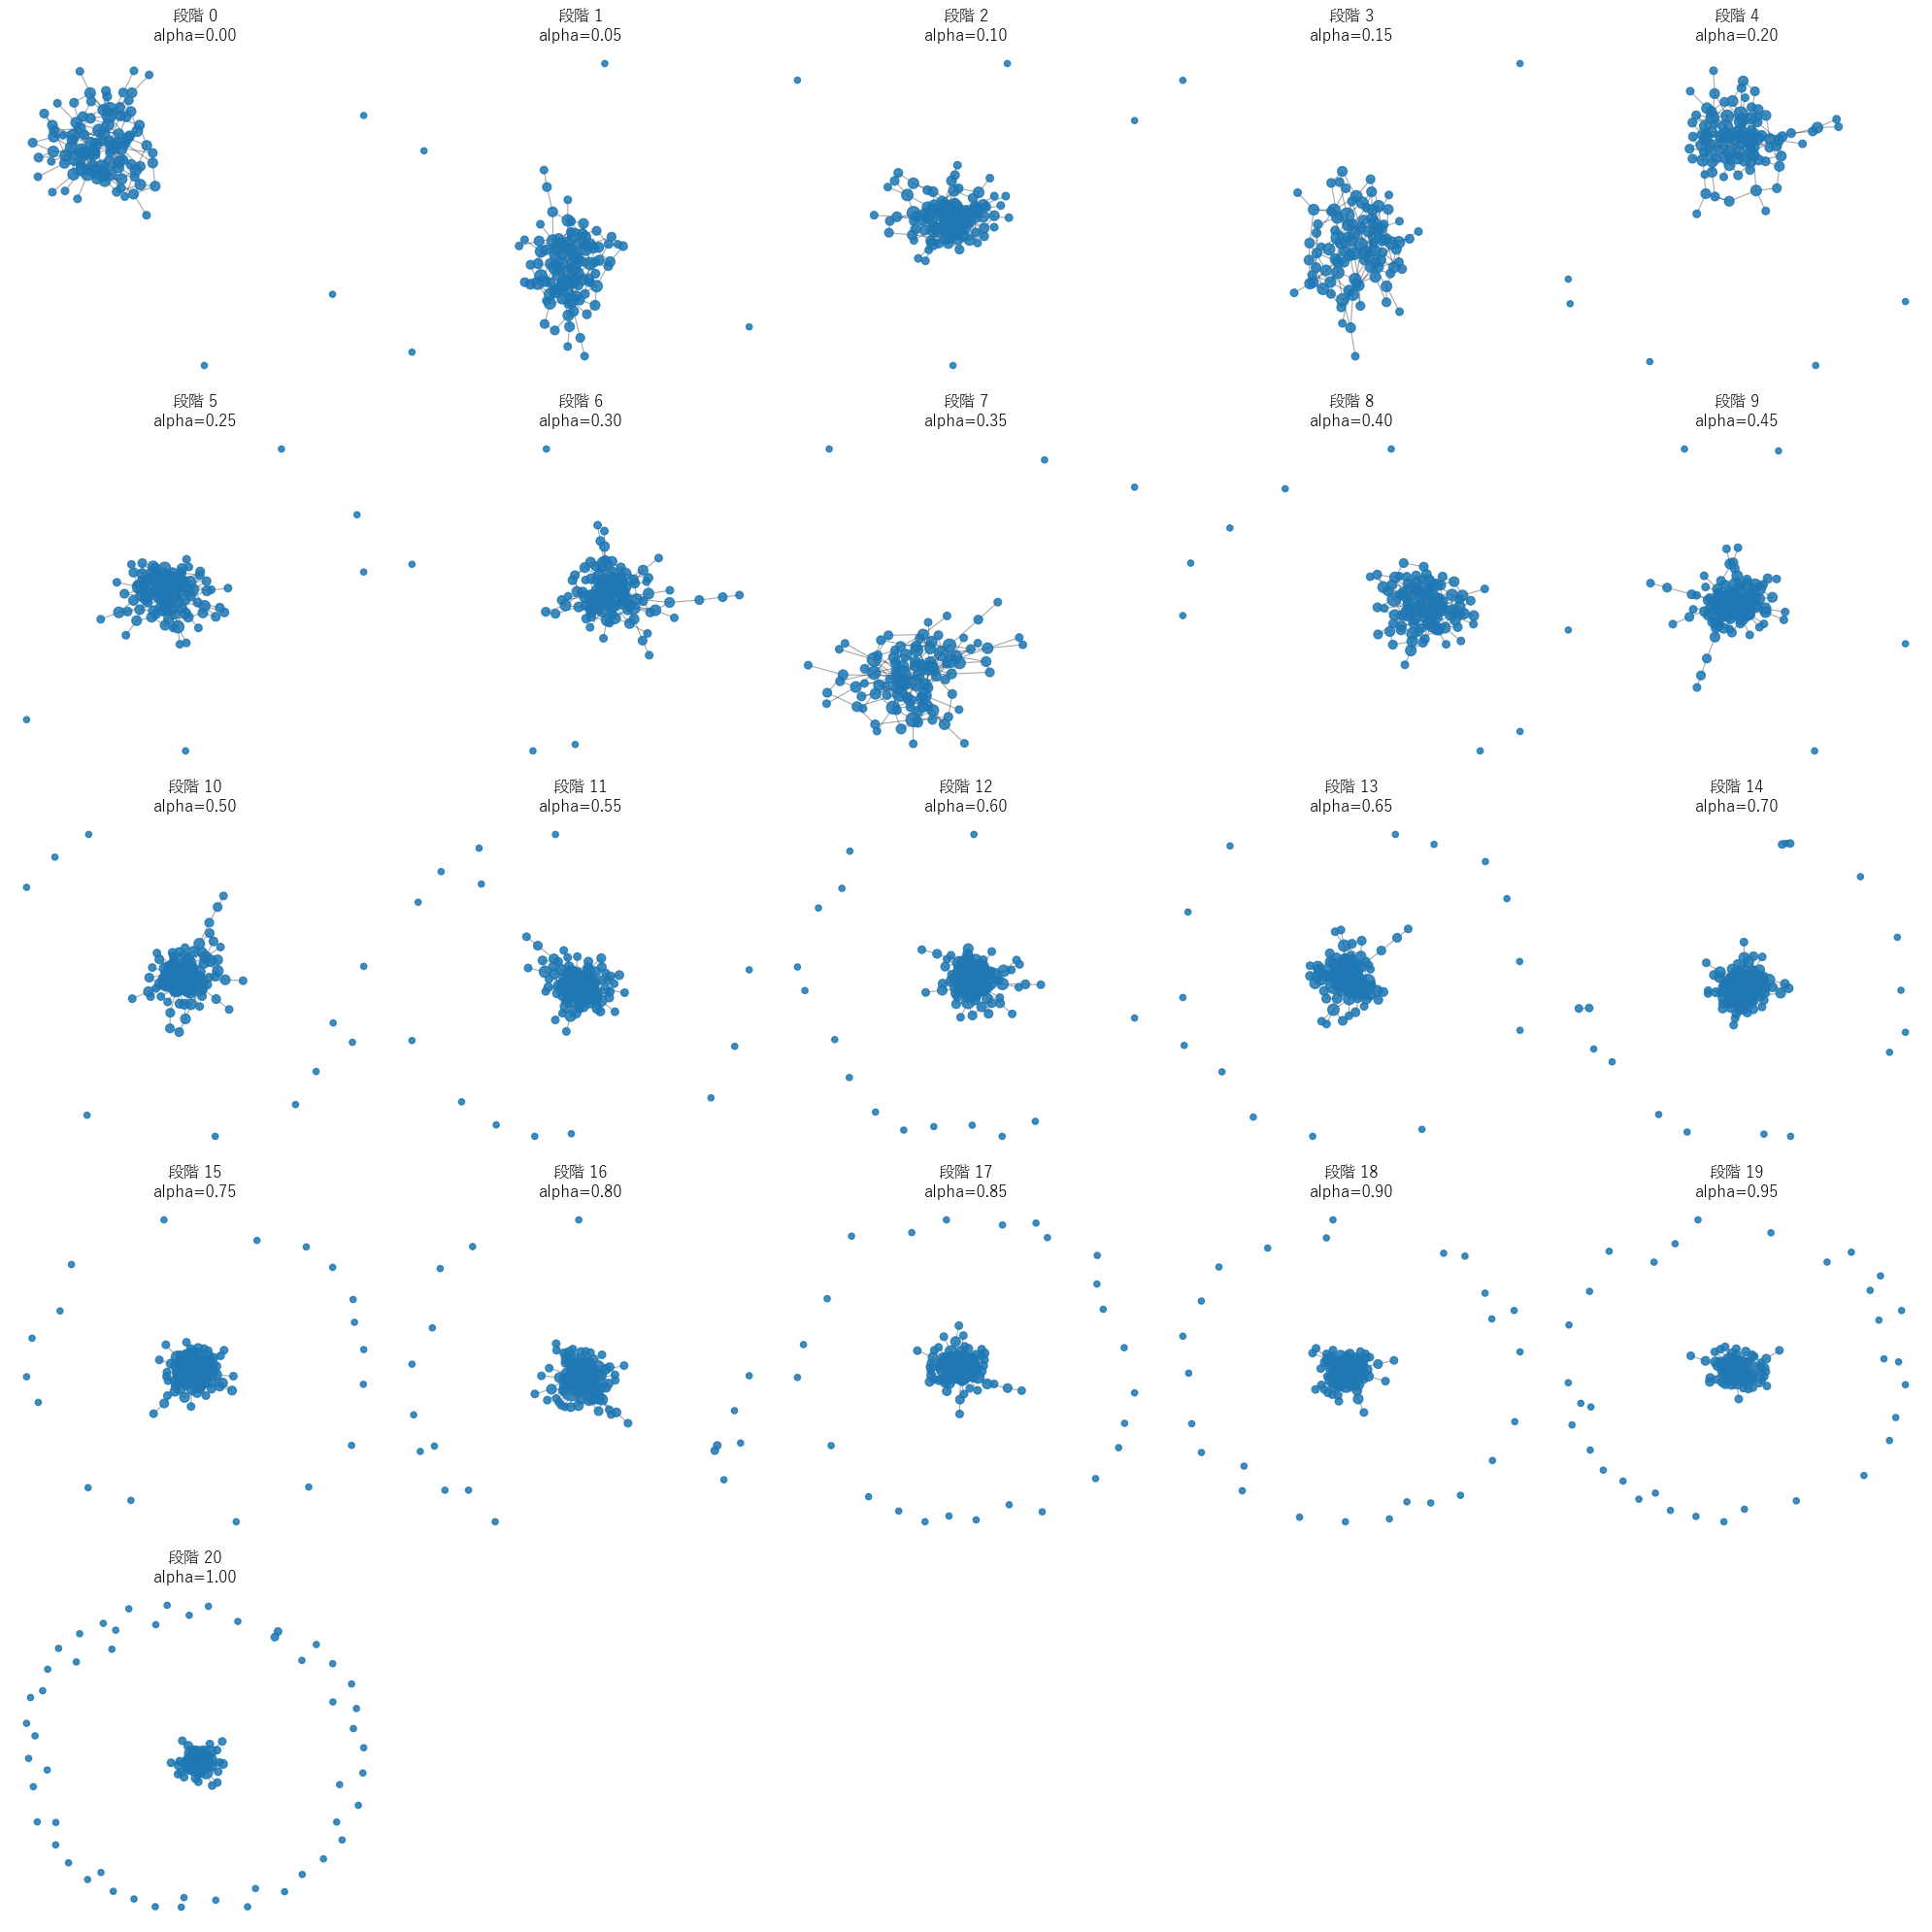

描画開始: 次数ヒストグラム


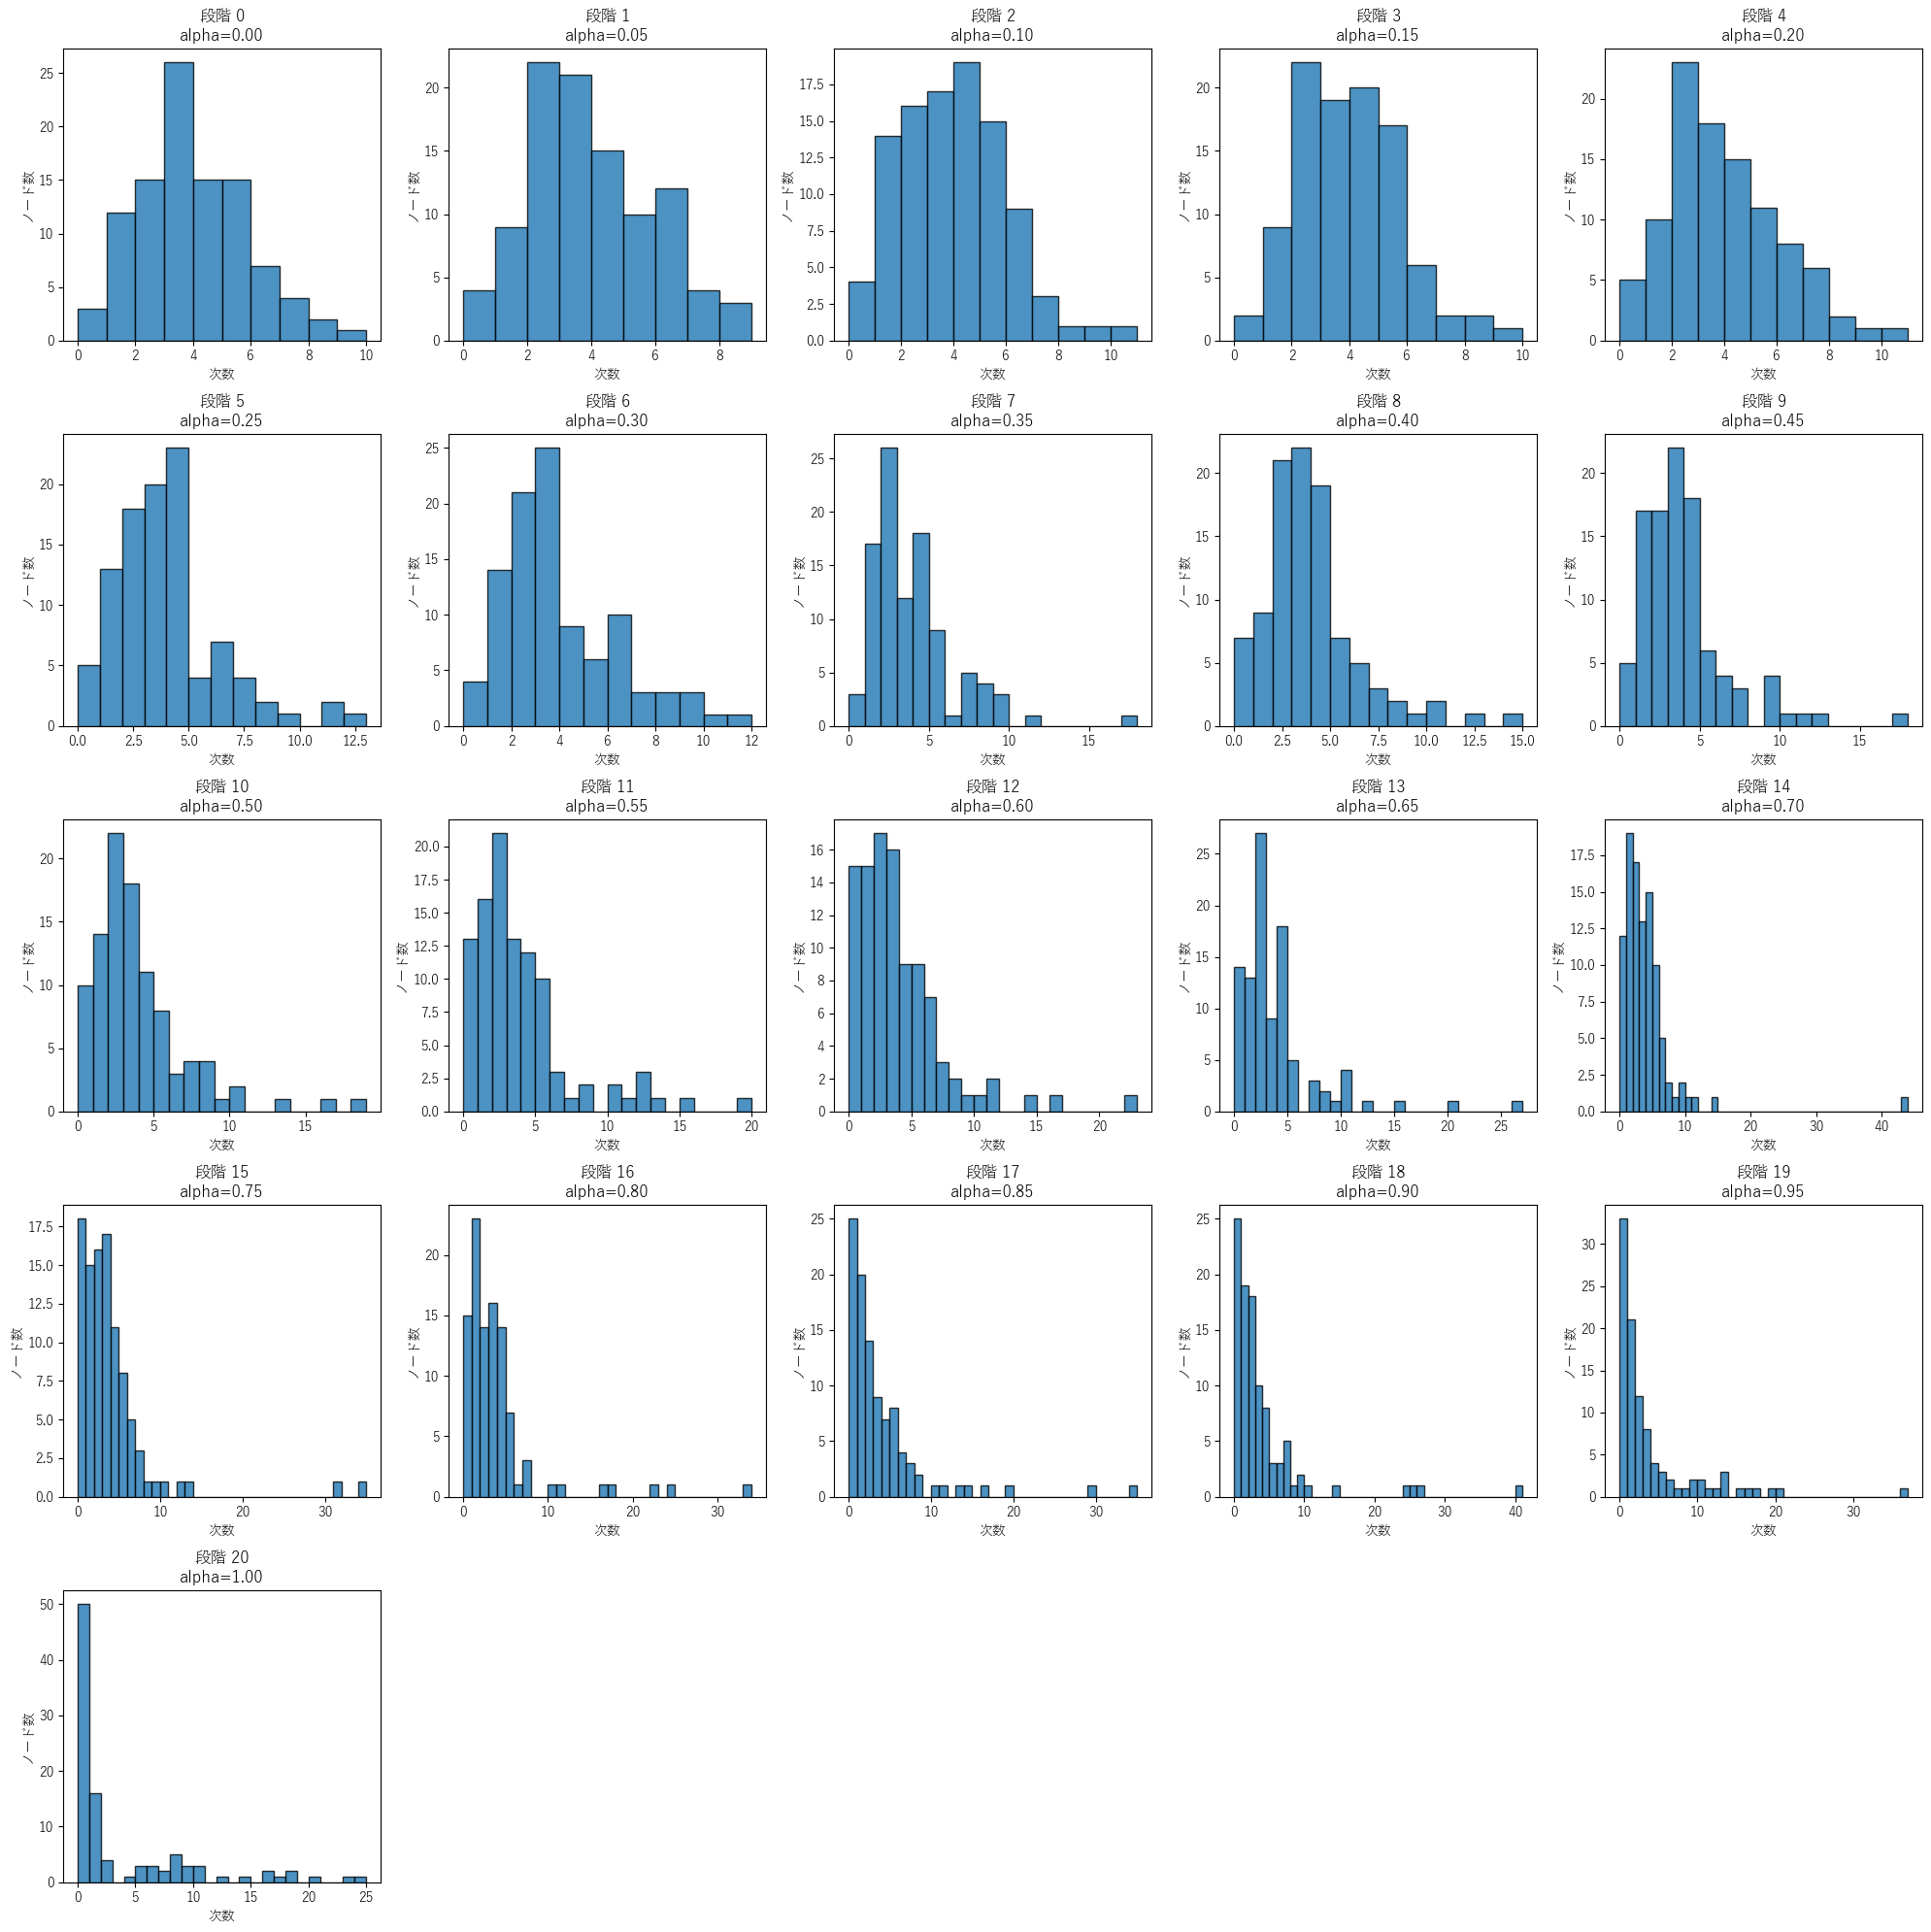

描画開始: 次数順位プロット


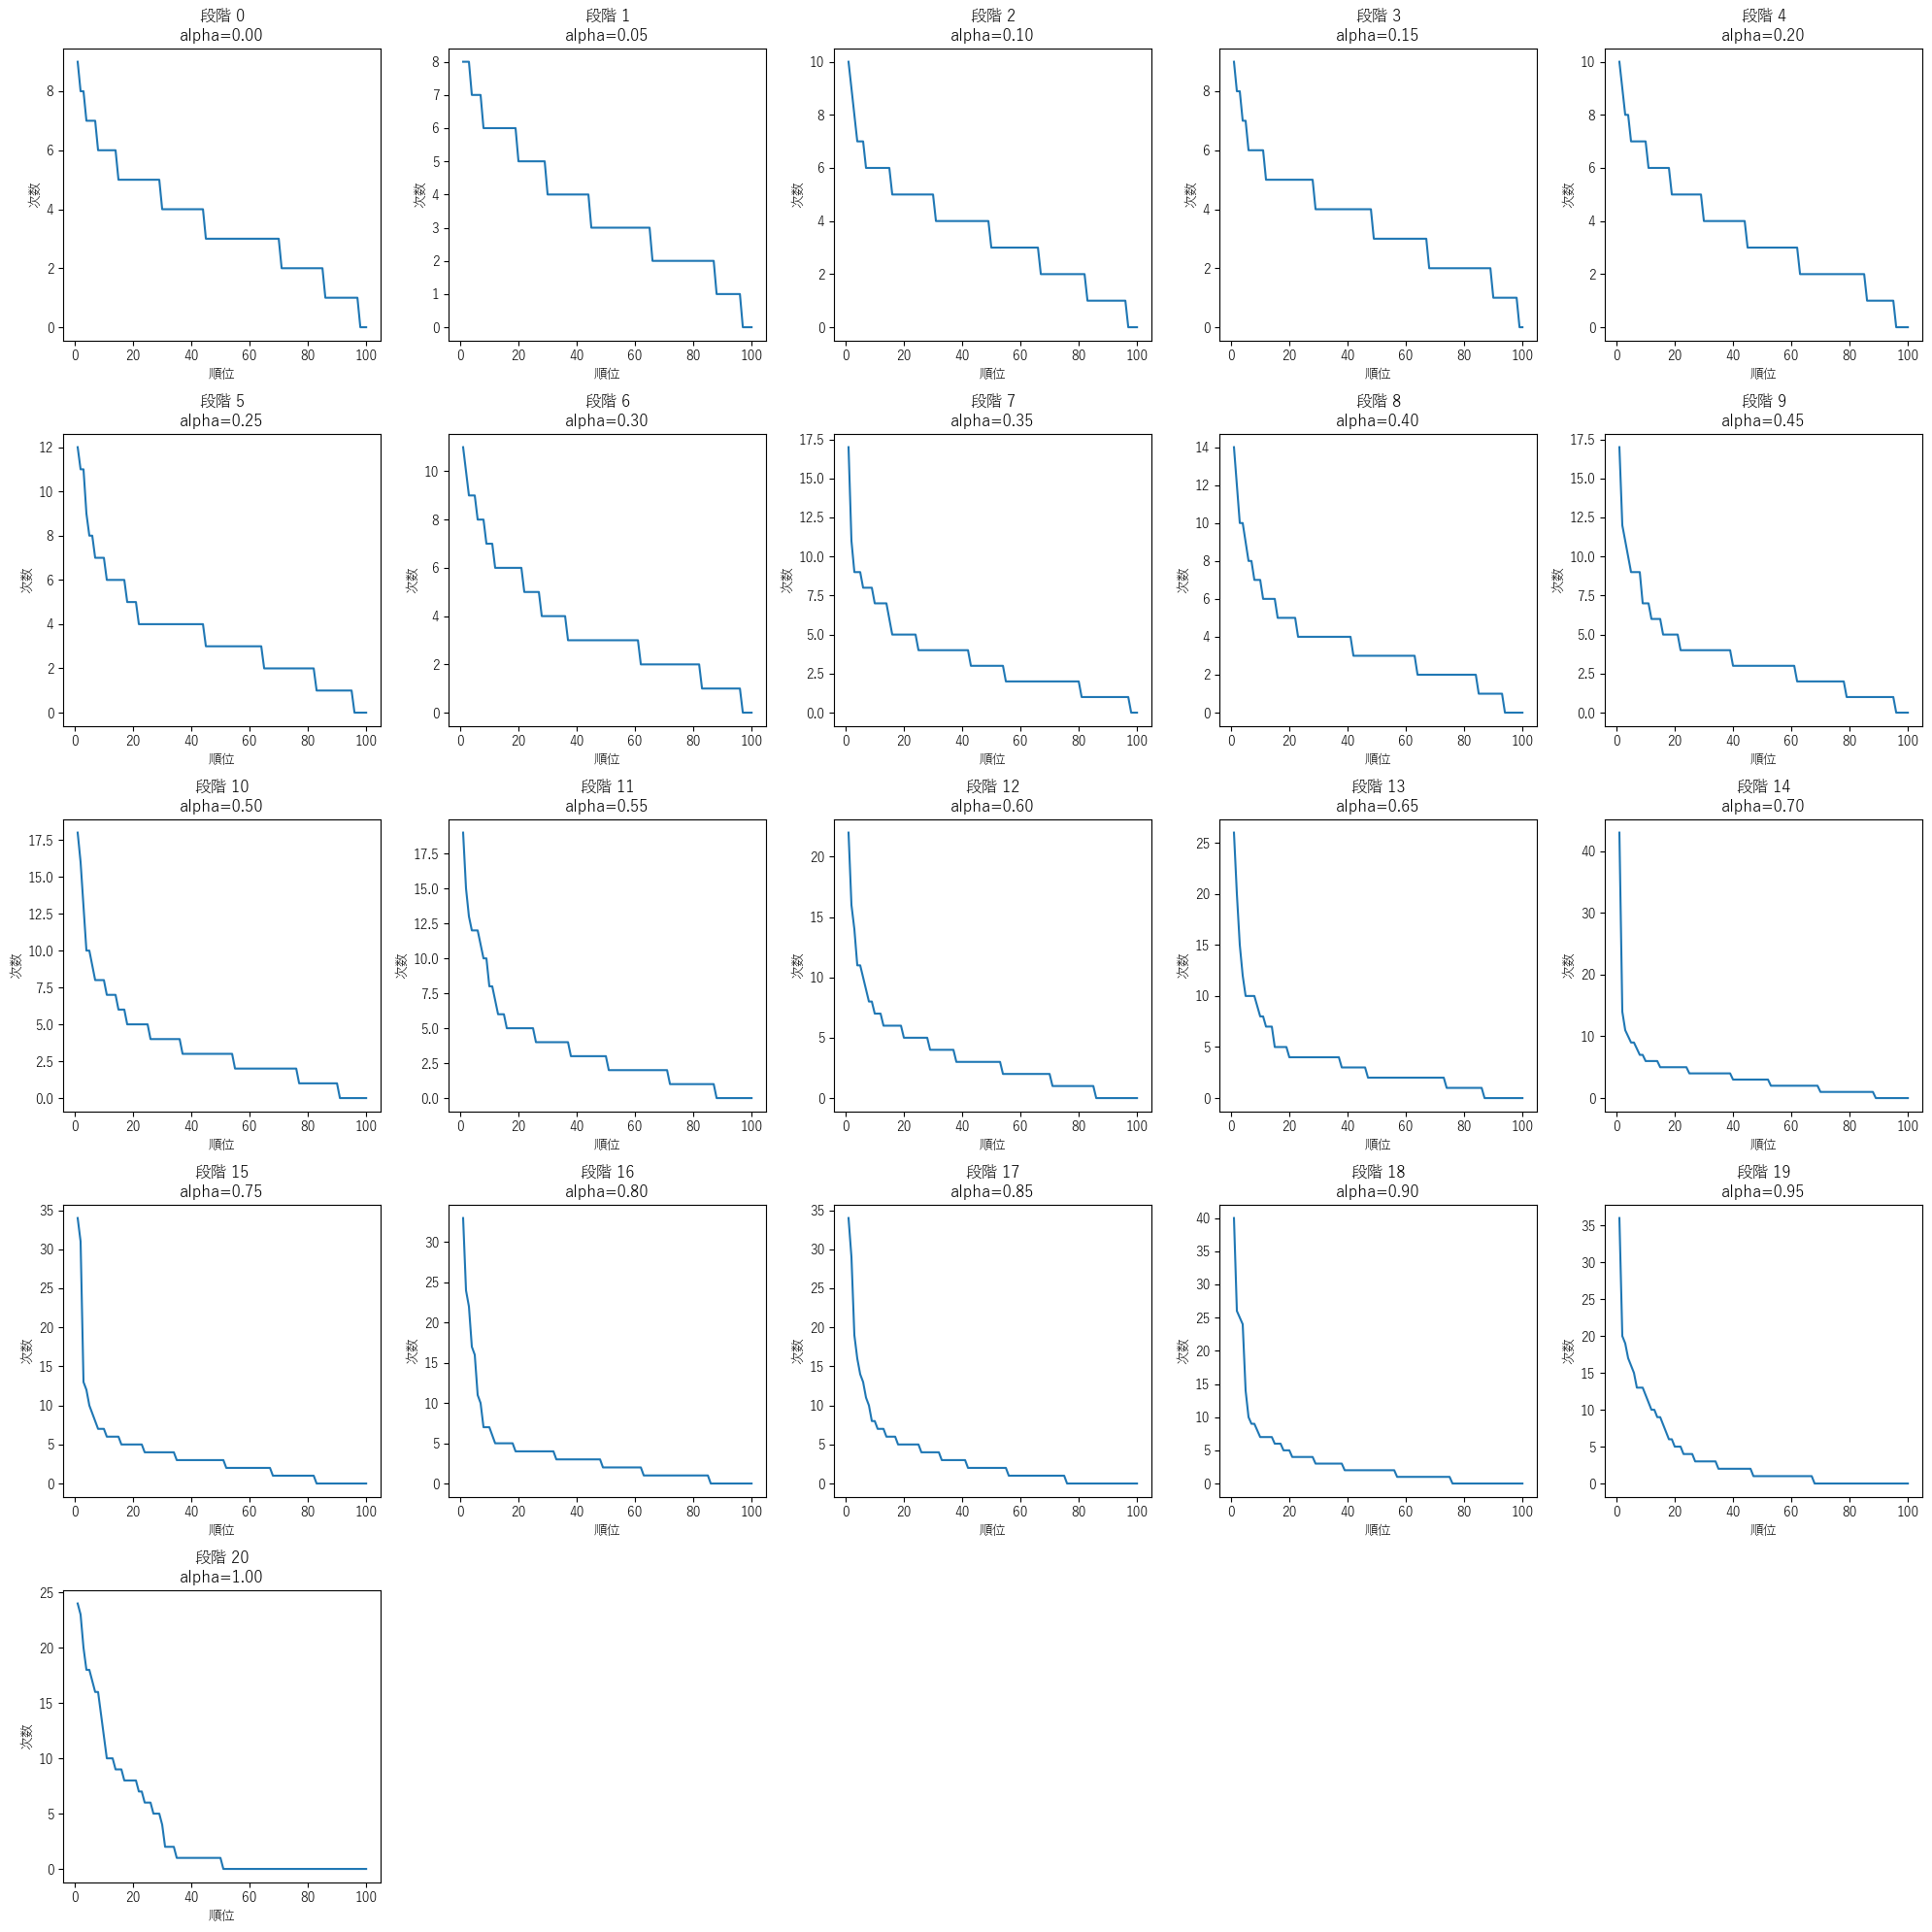

描画開始: ラプラシアン固有値列


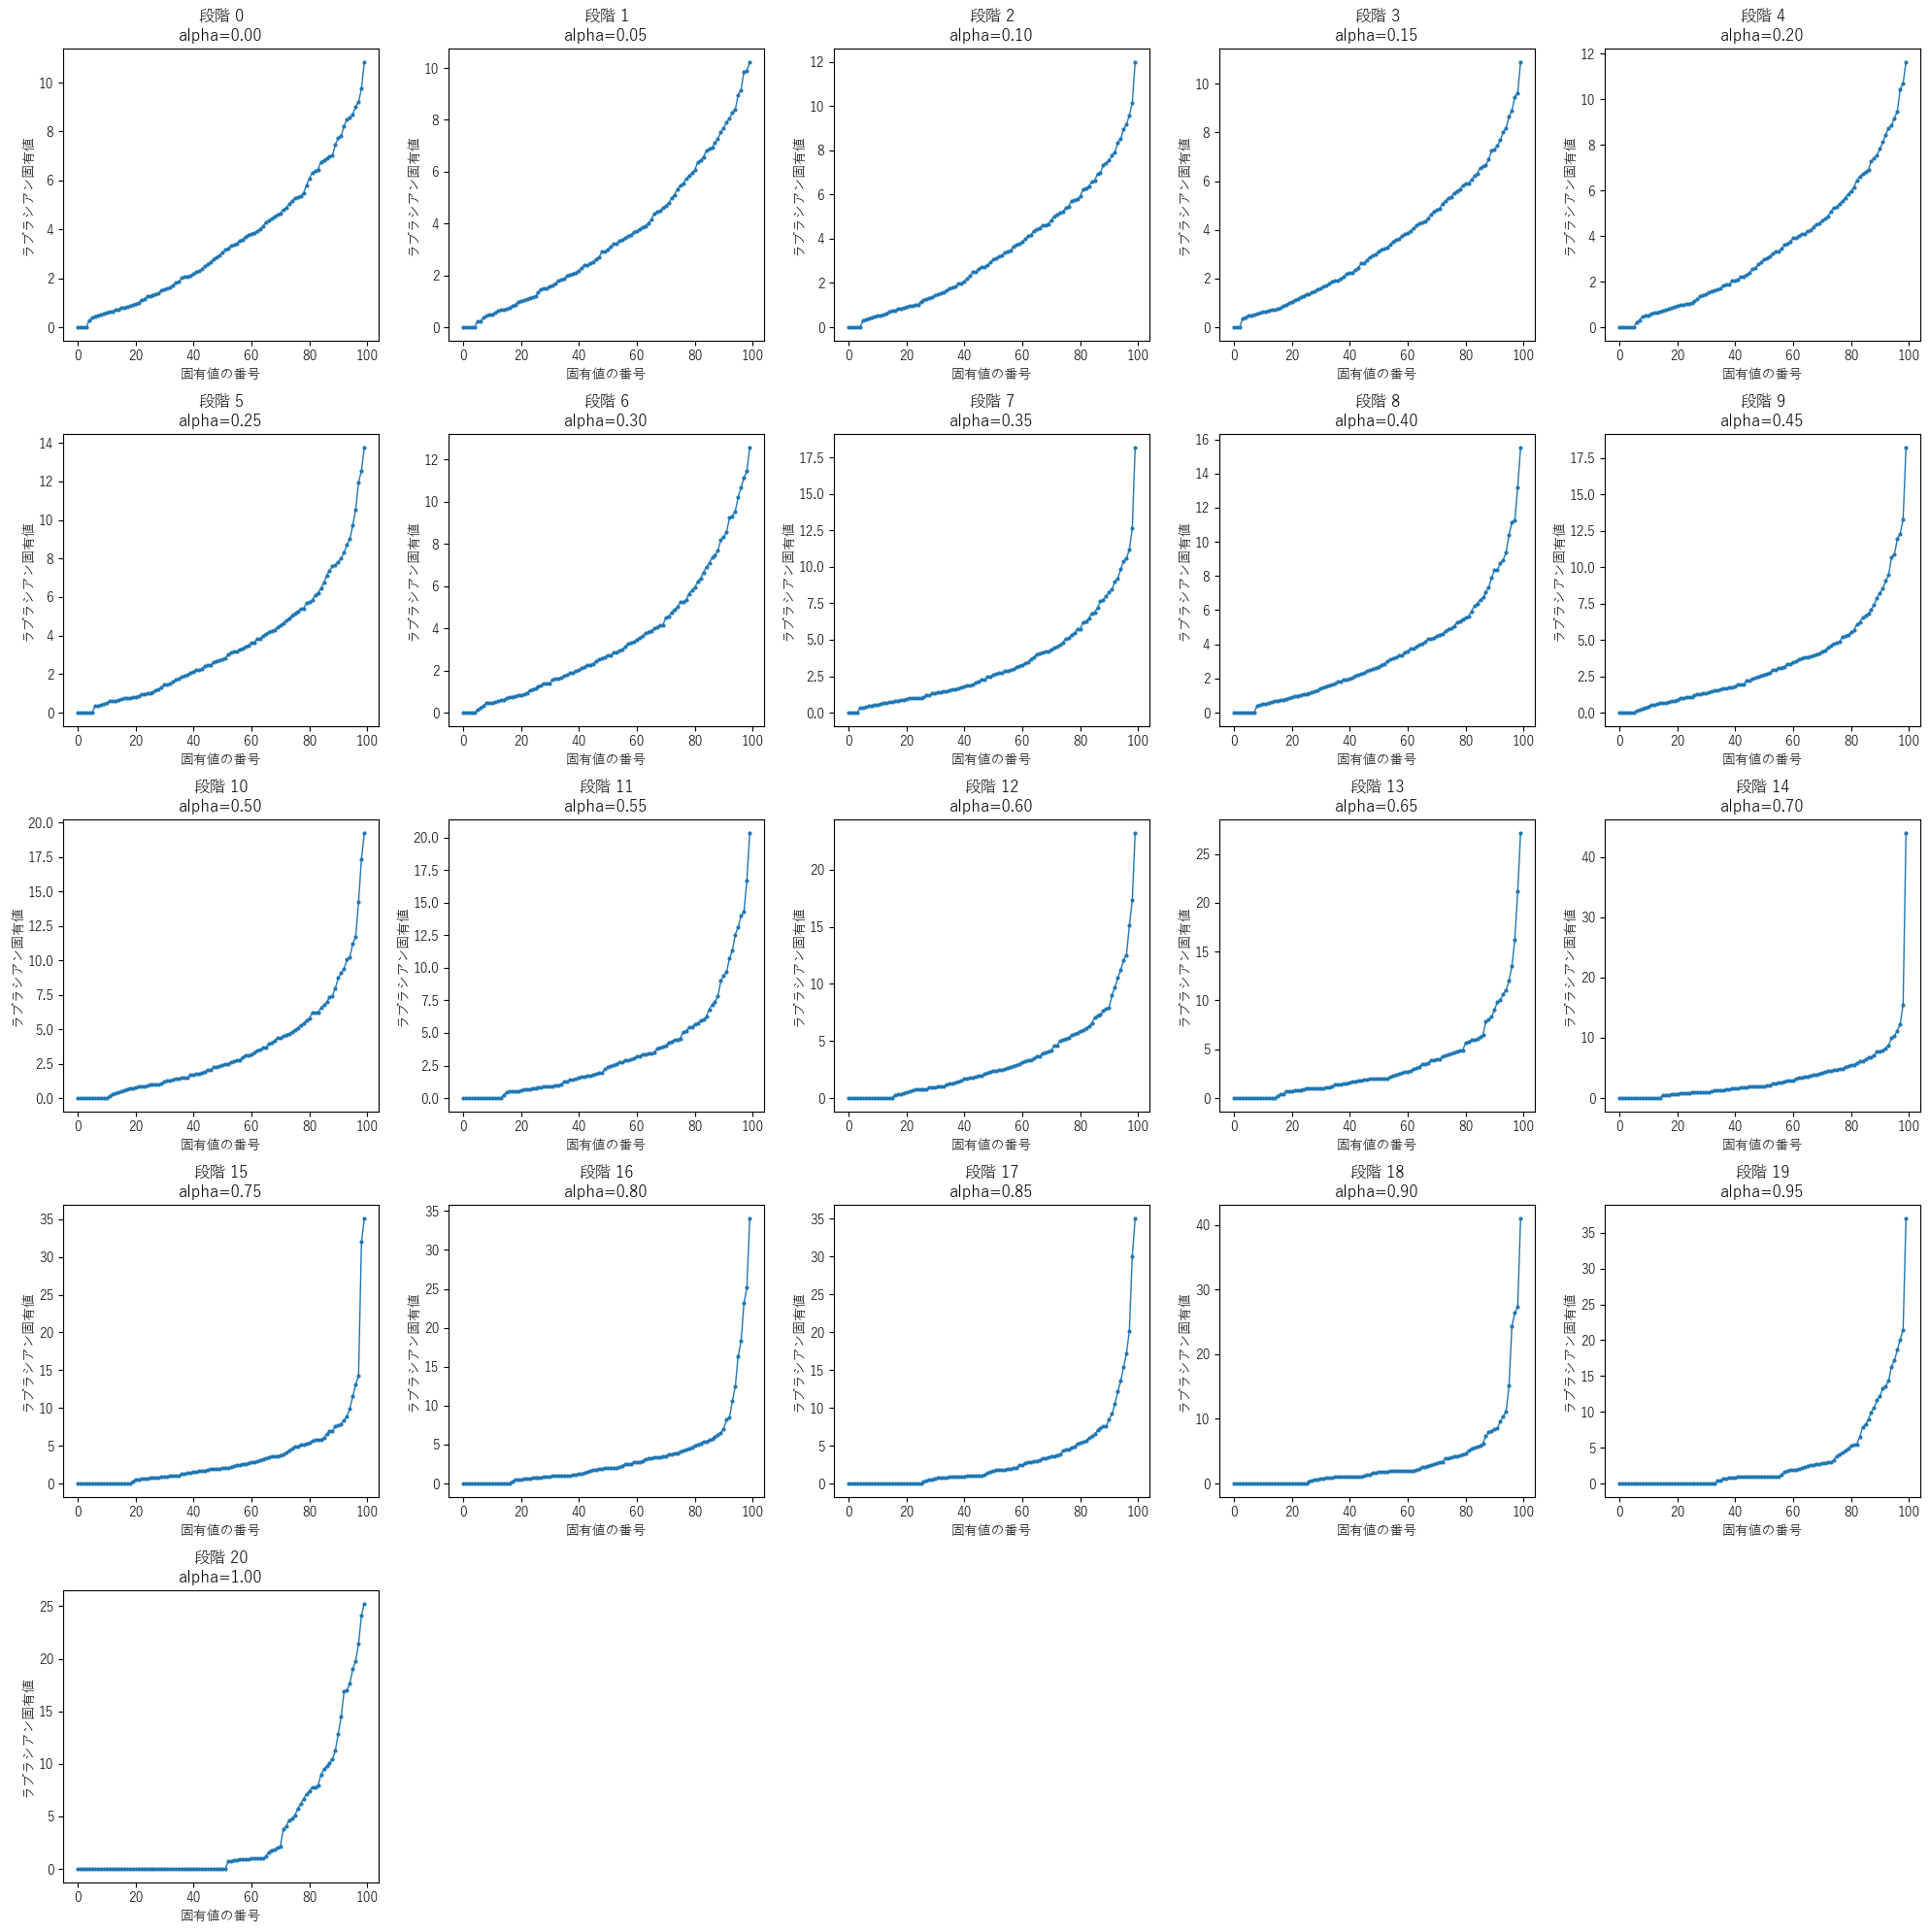

描画開始: ラプラシアンスペクトル要約


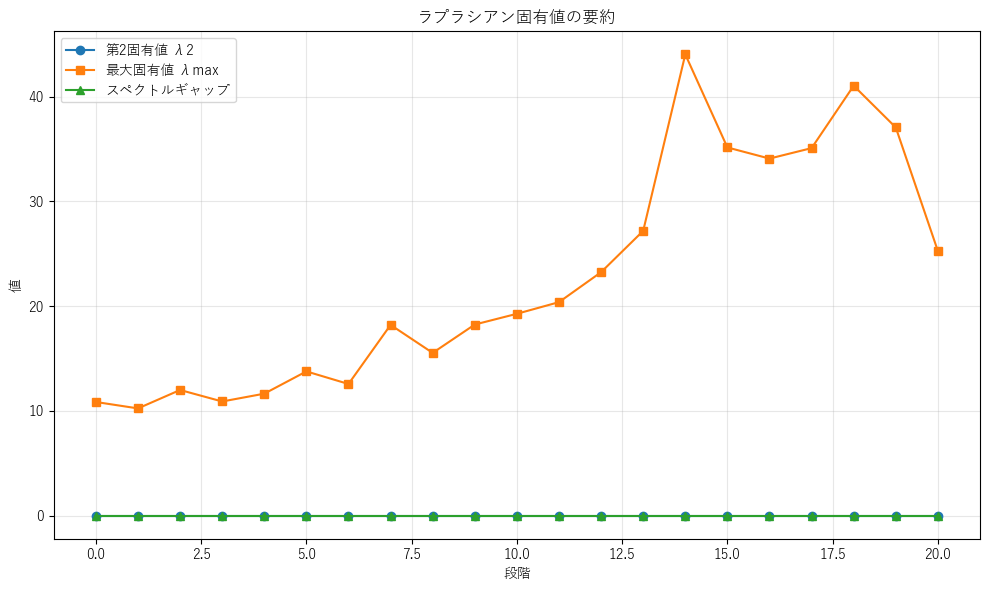

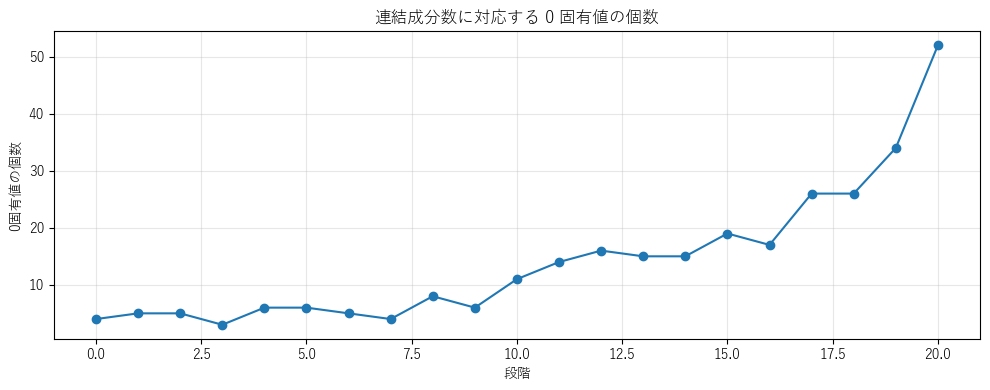

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.font_manager as fm


# =========================
# 日本語フォント設定
# =========================
def set_japanese_font():
    candidates = ["Yu Gothic", "MS Gothic", "Hiragino Sans", "IPAPGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    for c in candidates:
        if c in available:
            plt.rcParams["font.family"] = c
            return
    print("[WARNING] 日本語フォントが見つかりません。必要なら英語タイトルにしてください。")


set_japanese_font()


# =========================
# 基本設定
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# =========================
# ノード選択
# =========================
def choose_node_uniform(G):
    return random.choice(list(G.nodes()))


def choose_node_preferential(G, beta=1.8):
    nodes = list(G.nodes())
    deg = np.array([G.degree(n) + 1 for n in nodes], dtype=float)
    weights = deg ** beta
    weights /= weights.sum()
    return np.random.choice(nodes, p=weights)


def choose_node_mixed(G, alpha, beta=1.8):
    if random.random() < alpha:
        return choose_node_preferential(G, beta=beta)
    return choose_node_uniform(G)


# =========================
# スケールフリー寄りへ張り替え
# =========================
def rewire_graph_toward_scale_free(G, alpha, rewires_per_step=1000, beta=1.8):
    G = G.copy()

    for _ in range(rewires_per_step):
        edges = list(G.edges())
        if not edges:
            break

        u_old, v_old = random.choice(edges)
        G.remove_edge(u_old, v_old)

        added = False
        for _ in range(200):
            u = choose_node_mixed(G, alpha=alpha, beta=beta)
            v = choose_node_mixed(G, alpha=alpha, beta=beta)

            if u == v:
                continue
            if G.has_edge(u, v):
                continue

            G.add_edge(u, v)
            added = True
            break

        if not added and u_old != v_old and not G.has_edge(u_old, v_old):
            G.add_edge(u_old, v_old)

    return G


# =========================
# ラプラシアン固有値
# =========================
def compute_laplacian_eigenvalues(G):
    """
    非正規化ラプラシアン L = D - A の固有値
    """
    L = nx.laplacian_matrix(G).astype(float).toarray()
    eigvals = np.linalg.eigvalsh(L)
    eigvals = np.sort(np.real(eigvals))
    return eigvals


def summarize_spectrum(eigvals, tol=1e-8):
    """
    固有値の簡単な要約
    """
    zero_count = int(np.sum(np.abs(eigvals) < tol))
    lambda_1 = eigvals[0] if len(eigvals) >= 1 else np.nan
    lambda_2 = eigvals[1] if len(eigvals) >= 2 else np.nan
    lambda_max = eigvals[-1] if len(eigvals) >= 1 else np.nan
    spectral_gap = lambda_2 - lambda_1 if len(eigvals) >= 2 else np.nan

    return {
        "lambda_1": lambda_1,
        "lambda_2": lambda_2,
        "lambda_max": lambda_max,
        "spectral_gap": spectral_gap,
        "zero_count": zero_count,
    }


# =========================
# 描画
# =========================
def plot_transition(graphs, alphas):
    ncols = 5
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        pos = nx.spring_layout(G, seed=SEED)
        deg = np.array([G.degree(n) for n in G.nodes()])
        node_sizes = 20 + deg * 10

        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, alpha=0.85)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=0.8)

        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.axis("off")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_degree_distributions(graphs, alphas):
    ncols = 5
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        deg = [G.degree(n) for n in G.nodes()]
        bins = range(0, max(deg) + 2)

        ax.hist(deg, bins=bins, edgecolor="black", alpha=0.8)
        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.set_xlabel("次数")
        ax.set_ylabel("ノード数")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_degree_rank(graphs, alphas):
    ncols = 5
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        deg = sorted([G.degree(n) for n in G.nodes()], reverse=True)
        ax.plot(range(1, len(deg) + 1), deg)
        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.set_xlabel("順位")
        ax.set_ylabel("次数")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_laplacian_spectra(eigenvalues_list, alphas, max_points=None):
    """
    各段階の固有値列を描く
    """
    ncols = 5
    nrows = int(np.ceil(len(eigenvalues_list) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (eigvals, alpha) in enumerate(zip(eigenvalues_list, alphas)):
        ax = axes[i]

        vals = eigvals if max_points is None else eigvals[:max_points]
        ax.plot(range(len(vals)), vals, marker="o", markersize=2, linewidth=1)

        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.set_xlabel("固有値の番号")
        ax.set_ylabel("ラプラシアン固有値")

    for j in range(len(eigenvalues_list), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_spectral_summary(summary_list, alphas):
    steps = list(range(len(summary_list)))
    lambda2 = [s["lambda_2"] for s in summary_list]
    lmax = [s["lambda_max"] for s in summary_list]
    zero_counts = [s["zero_count"] for s in summary_list]
    gaps = [s["spectral_gap"] for s in summary_list]

    plt.figure(figsize=(10, 6))
    plt.plot(steps, lambda2, marker="o", label="第2固有値 λ2")
    plt.plot(steps, lmax, marker="s", label="最大固有値 λmax")
    plt.plot(steps, gaps, marker="^", label="スペクトルギャップ")
    plt.xlabel("段階")
    plt.ylabel("値")
    plt.title("ラプラシアン固有値の要約")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(steps, zero_counts, marker="o")
    plt.xlabel("段階")
    plt.ylabel("0固有値の個数")
    plt.title("連結成分数に対応する 0 固有値の個数")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def print_spectral_summary(summary_list, alphas):
    print("\n===== ラプラシアン固有値の要約 =====")
    print("段階 | alpha | λ1 | λ2 | λmax | gap | 0固有値個数")
    print("-" * 72)
    for i, (s, alpha) in enumerate(zip(summary_list, alphas)):
        print(
            f"{i:>4} | "
            f"{alpha:>5.2f} | "
            f"{s['lambda_1']:>8.4f} | "
            f"{s['lambda_2']:>8.4f} | "
            f"{s['lambda_max']:>8.4f} | "
            f"{s['spectral_gap']:>8.4f} | "
            f"{s['zero_count']:>6}"
        )


# =========================
# メイン
# =========================
def main():
    n = 100
    p = 0.04
    steps = 20
    rewires_per_step = 1000
    beta = 1.8

    G = nx.erdos_renyi_graph(n=n, p=p, seed=SEED)

    graphs = [G.copy()]
    alphas = [0.0]

    print("変形開始")
    print(f"ノード数 = {n}, 初期確率 p = {p}, 段階数 = {steps}")
    print(f"rewires_per_step = {rewires_per_step}, beta = {beta}")

    for step in range(1, steps + 1):
        alpha = step / steps
        print(f"[途中経過] 段階 {step}/{steps} : alpha = {alpha:.2f}")

        G = rewire_graph_toward_scale_free(
            G,
            alpha=alpha,
            rewires_per_step=rewires_per_step,
            beta=beta
        )

        graphs.append(G.copy())
        alphas.append(alpha)

    # ラプラシアン固有値計算
    eigenvalues_list = []
    spectral_summary = []

    print("\nラプラシアン固有値を計算中")
    for i, G in enumerate(graphs):
        eigvals = compute_laplacian_eigenvalues(G)
        summary = summarize_spectrum(eigvals)

        eigenvalues_list.append(eigvals)
        spectral_summary.append(summary)

        print(
            f"[固有値計算] 段階 {i:>2} | "
            f"λ2={summary['lambda_2']:.4f}, "
            f"λmax={summary['lambda_max']:.4f}, "
            f"0固有値個数={summary['zero_count']}"
        )

    print_spectral_summary(spectral_summary, alphas)

    print("\n描画開始: グラフ構造")
    plot_transition(graphs, alphas)

    print("描画開始: 次数ヒストグラム")
    plot_degree_distributions(graphs, alphas)

    print("描画開始: 次数順位プロット")
    plot_degree_rank(graphs, alphas)

    print("描画開始: ラプラシアン固有値列")
    plot_laplacian_spectra(eigenvalues_list, alphas)

    print("描画開始: ラプラシアンスペクトル要約")
    plot_spectral_summary(spectral_summary, alphas)


if __name__ == "__main__":
    main()